# Predicting location of hyperbolas Instance Segmentation

In this Notebook it is the same case as in the Notebook **4 Predicting_location_of_hyperbolas_Object_Detection** but that the model used is a instance segmentation Model.

- Chapter 1: Load Yolo Model
- Chapter 2: Predicting Locations of Hyperbolas with YOLO Model
- Chapter 3: Extracting Bounding Boxes and Polygons
- Chapter 4: Create a file out of the Predictions and Convert the Predictions to 3D
- Chapter 5: Fitting Hyperbolas with Multiple Linear Regression
- Chapter 6: Interactive Plot
- Chapter 7: Implementation in Pipeline



### Chapter 1: Load Yolo Model

following code shows loading a Yolo Model directly threw the **ultralytics** Library.

In [1]:
#import libraries
import numpy as np
from ultralytics import YOLO

#Setting Working directory
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *




In [2]:
#Load trained Model for Instance Segmentation for Hyperbolas
model = YOLO(YOLO_MODEL_SEG_H_DIR)


Load the Datatoolkit and create Test Images if wanted via the Datatoolkit. Option 2 is to use the Test set of Roboflow.

In [3]:
from Pipeline.Datatoolkit import DatatoolKit

dk1 = DatatoolKit(TEST_FILE_DIR , "EG-3D QUER001.SGY")
dk2 = DatatoolKit(TEST_FILE_DIR , "UG3DQUERUNTERZUG.SGY")
file1 = dk1.LoadSGY()
file2 = dk2.LoadSGY()
df1 = dk1.create_df(file1)
df2 = dk2.create_df(file2)

In [6]:
dk1.create_images(file=file1, df=df1, outdir=TEST_PIC_SEG_H_DIR, inline=True)

saved 71 images to c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\EG-3D QUER001.SGY_inline_71.png


In [ ]:
dk2.create_images(file=file2, df= df2, outdir=TEST_PIC_SEG_H_DIR, inline=True)

saved 60 images to c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\pictures\UG3DQUERUNTERZUG.SGY_inline_60.png


## Chapter 2: Predicting Locations of Hyperbolas with YOLO Model

In [7]:
results = model.predict(TEST_PIC_SEG_H_DIR,save =True, conf=0.2, show_boxes = True)


image 1/132 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\EG-3D QUER001.SGY_inline_0.png: 128x640 2 hyperbolas, 54.5ms
image 2/132 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\EG-3D QUER001.SGY_inline_1.png: 128x640 2 hyperbolas, 28.5ms
image 3/132 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\EG-3D QUER001.SGY_inline_10.png: 128x640 14 hyperbolas, 31.1ms
image 4/132 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\EG-3D QUER001.SGY_inline_11.png: 128x640 5 hyperbolas, 30.6ms
image 5/132 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\EG-3D QUER001.SGY_inline_12.png: 128x640 13 hyperbolas, 32.4ms
image 6/132 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\EG-3D QUER001.SGY_inline_13.png: 128x640 7 hyperbolas, 29.9ms
image 7/132 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\EG-3


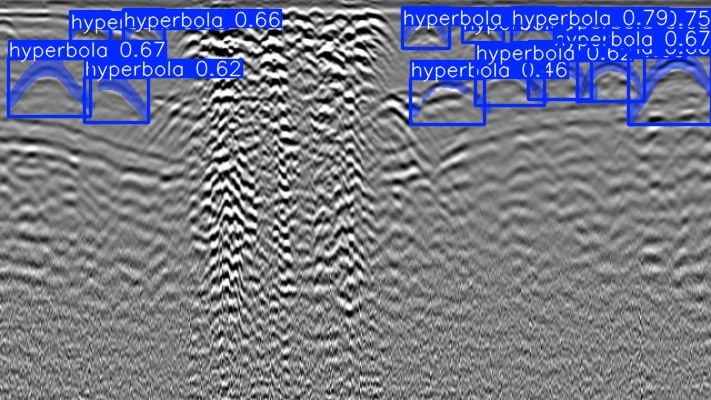

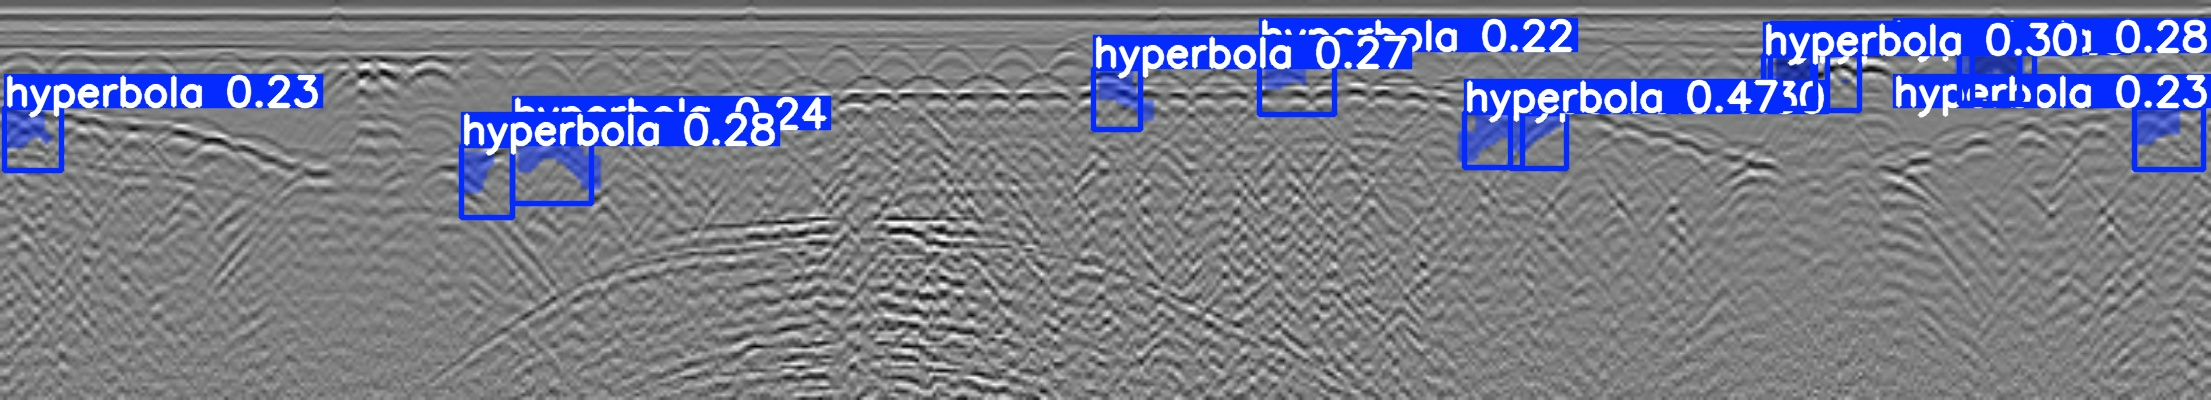

Out of these two examples it can be directly seen that this type of Model works better as the Object Detections. But for the Second Picture note as much is detectet as hoped but this could be a reason to not al lot of trainingsdata.

## Chapter 3: Extracting Bounding Boxes and Polygons

Now modifying the Function which was created in **4 Predicting_location_of_hyperbolas_Object_Detection.ipynb** and adjust it so it can extract the polygons and bounding boxes.

In [8]:
import os
import numpy as np

def extract_boxes_and_polygons(results)-> dict:
    
    all_results = {}

    for result in results:
        img_name = os.path.basename(result.path)
        data = {}
        if result.boxes is not None:
            data["boxes"] = result.boxes.xyxy.cpu().numpy()
            data["conf"] = result.boxes.conf.cpu().numpy()
            
        else:
            data["boxes"] = np.empty((0,4)) 
            data["conf"] = np.empty((0,))      
        
        if hasattr(result, "masks") and result.masks is not None:
            print("found polys")
            polygons = [mask.xy[0].tolist() for mask in result.masks]
            data["polygons"] = polygons
            
        
        else:
            data["polygons"] = []

        all_results[img_name] = data
    return all_results

In [5]:
preds = extract_boxes_and_polygons(results)
print(preds)

found polys
found polys
found polys
found polys
found polys
found polys
found polys
found polys
found polys
{'EG-3D QUER001.SGY_inline_15.png': {'boxes': array([[     396.41,      50.695,       471.7,      114.78],
       [      437.5,      156.54,      505.19,      229.03],
       [     1866.5,      155.15,      1965.5,      250.02],
       [     1735.2,      46.499,      1817.3,       111.1]], dtype=float32), 'conf': array([     0.5658,     0.56179,      0.5484,     0.51444], dtype=float32), 'polygons': [[[393.8343505859375, 54.90312576293945], [393.8343505859375, 92.9046859741211], [404.19842529296875, 92.9046859741211], [411.1077880859375, 85.99530792236328], [414.5625, 85.99530792236328], [418.0171813964844, 82.5406265258789], [421.47186279296875, 82.5406265258789], [424.9265441894531, 79.0859375], [428.3812255859375, 79.0859375], [431.8359375, 75.6312484741211], [435.2906188964844, 75.6312484741211], [445.6546630859375, 85.99530792236328], [449.109375, 85.99530792236328], [456.01

### Chapter 4: Create a file out of the Predictions and Convert the Predictions to 3D

The goal is to create a CSV file that contains:

1. All bounding boxes that are indexed, and

2. All polygons that are associated with—or derived from—those bounding boxes.

The main challenge is to establish a clear relationship between the images, their bounding boxes, and the corresponding polygon segments.

The first step is to define a well-structured schema for the CSV file.
This schema will specify:

1. which information each entry must contain,

2. how bounding boxes and polygons are linked together,

3. and how images are uniquely referenced

The Structure looks like the following:
|filename|cut_type|cut_number|bbox_number|bbox_data|polygon_data|
|-|-|-|-|-|-|
|file1|inline|1|1|[20,30,40,50]|Ponits of polygon in bbox|

to recreate the structure the extracting function from **Chapter 3** needs to be adjusted.

In [5]:
import os
import numpy as np
import re
import pandas as pd
import json

def match_detections(results, dist_trheshhold:int=20, export_csv:bool = False, save_path:str = None):
    global_boxes = []
    global_id = 0
    records = []

    def center_bbox(box):
        x1,y1,x2,y2 = box
        return ((x1+x2)/2, (y1+y2)/2)
    
    def euclidan_distance(c1, c2):
        return np.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)
    
    def parse_filename(filename):
        base_name = os.path.basename(filename)
        
        #getting everything until SGY
        match_main = re.match(r"(.+?\.SGY)", base_name, re.IGNORECASE)
        filename_part = match_main.group(1) if match_main else base_name

        #getting cut_type and cut_number
        match_suffix = re.search(r"_(\w+)[_-](\d+)", base_name)
        cut_type = match_suffix.group(1) if match_suffix else "unknown"
        cut_number = int(match_suffix.group(2)) if match_suffix else -1

        return filename_part, cut_type, cut_number



    for result in results:
        img = os.path.basename(result.path)
        filename, cut_type, cut_number = parse_filename(img)

        if result.boxes is not None:
            boxes = result.boxes.xyxy.cpu().numpy()
           
        else:
            boxes = np.empty((0,4)) 
                  
        
        if hasattr(result, "masks") and result.masks is not None:
            polygons = [mask.tolist() for mask in result.masks.xy]
            
        else:
            polygons = []

        for i, box in enumerate(boxes):
            center = center_bbox(box)
            existing_id = None

            for gid, gcenter in global_boxes:
                if euclidan_distance(center, gcenter)< dist_trheshhold:
                    existing_id = gid
                    break
            
            if existing_id is None:
                existing_id = global_id
                global_boxes.append((global_id,center))
                global_id +=1

            polygon_data = json.dumps(polygons[i] if i < len(polygons) else [])
            bbox_data = json.dumps(box.tolist())
            

            records.append({
                "filename": filename,
                "cut_type": cut_type,
                "cut_number": cut_number,
                "bbox_number": existing_id,
                "bbox_data": bbox_data,
                "polygon_data": polygon_data
            })

    matched_detections = pd.DataFrame(records)
    if export_csv:
        matched_detections.to_csv(f"{save_path}/results.csv", index=False)
        return matched_detections
    else:
        return matched_detections

Next step is to test the function

In [6]:
matched_detections = match_detections(results= results, dist_trheshhold=20, save_path=OUT_PATH_Detections, export_csv=True )

In [6]:
matched_detections

,filename,cut_type,cut_number,bbox_number,bbox_data,polygon_data
0,UG3DQUERUNTERZUG.SGY,inline,1,0,"[564.8929443359375, 9.323530197143555, 606.538...","[[575.4656372070312, 11.140625], [575.46563720..."
1,UG3DQUERUNTERZUG.SGY,inline,1,1,"[119.51518249511719, 7.599554538726807, 165.42...","[[133.3125, 6.696875095367432], [133.3125, 11...."
2,UG3DQUERUNTERZUG.SGY,inline,1,2,"[512.0293579101562, 8.925403594970703, 553.642...","[[522.140625, 11.140625], [522.140625, 14.4734..."
3,UG3DQUERUNTERZUG.SGY,inline,1,3,"[457.6700439453125, 9.530701637268066, 501.564...","[[469.92657470703125, 11.140625], [469.9265747..."
4,UG3DQUERUNTERZUG.SGY,inline,1,4,"[520.1708374023438, 60.12672805786133, 594.235...","[[543.2484130859375, 60.02187728881836], [543...."
...,...,...,...,...,...,...
738,UG3DQUERUNTERZUG.SGY,inline,9,15,"[467.36358642578125, 59.840248107910156, 542.1...","[[488.8125, 60.02187728881836], [488.8125, 63...."
739,UG3DQUERUNTERZUG.SGY,inline,9,10,"[277.7679748535156, 11.377150535583496, 317.78...","[[287.7328186035156, 11.140625], [287.73281860..."
740,UG3DQUERUNTERZUG.SGY,inline,9,6,"[574.64453125, 56.791709899902344, 639.8307495...","[[595.4625244140625, 55.578125], [595.46252441..."
741,UG3DQUERUNTERZUG.SGY,inline,9,5,"[399.19329833984375, 9.326848030090332, 444.06...","[[411.046875, 11.140625], [411.046875, 15.5843..."


looks promising with respect to the Dataframme. But for better intepreatation a plot is needed and if its matching with the detections from YOLO.

In [41]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
def plot_matched_detections(df, csv:bool=False, csv_path:str = None):

    if csv:
        df = pd.read_csv(csv_path)
    else:
        df = df

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(projection='3d')

    for i, row in df.iterrows():

        cut_number = row["cut_number"]
        polys = row["polygon_data"]
        bbox_number = row["bbox_number"]

        try:
            polygon = json.loads(polys)
        
        except json.JSONDecodeError:
            continue

        if not polygon or not isinstance(polygon[0], (list, tuple)):
            continue
        
        xs = [p[0] for p in polygon]
        zs = [p[1] for p in polygon]
        ys = [cut_number]

        color = cm.tab20(int(bbox_number)%20)
        ax.plot(xs, ys, zs, color = color, linewidth = 0.8,alpha = 0.5)

    ax.set_xlim(0,711)
    ax.set_zlim(0,400)
    ax.set_xlabel("X Values Polygons")
    ax.set_ylabel("Cut_number")
    ax.set_zlabel("Y Values Polygons")
    ax.invert_zaxis()

    ax.set_title("3D Plot of Detections")

    plt.show()



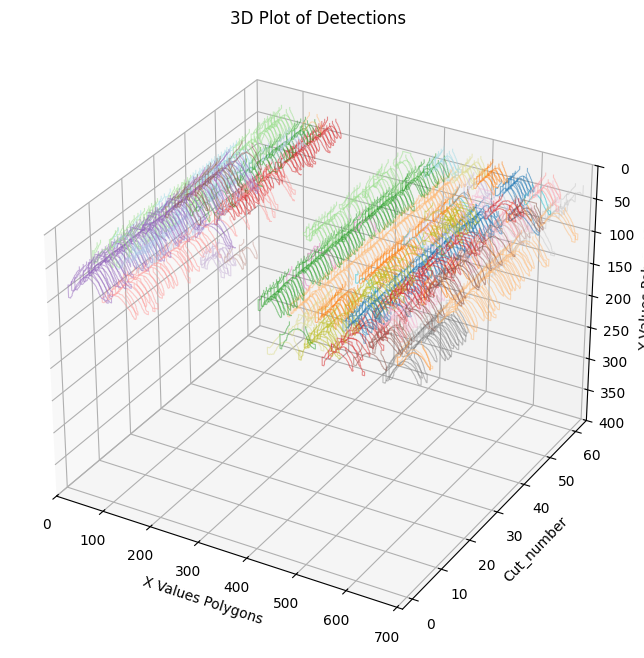

In [ ]:
plot_matched_detections(df=matched_detections)

out of the first plot its not realy clear which hyperbolas are on which inline so the next plot adds those spheres.

In [45]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
def plot_matched_detections(df, csv:bool=False, csv_path:str = None):

    xlim = (0,711)
    zlim = (0,400)

    if csv:
        df = pd.read_csv(csv_path)
    else:
        df = df

    fig = plt.figure(figsize=(15,15))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect([1,1,1])

    cuts = sorted(df["cut_number"].unique())
    X, Z = np.meshgrid(np.linspace(xlim[0],xlim[1],10),
                       np.linspace(zlim[0], zlim[1], 10))
    
    for cut in cuts:
        Y = np.ones_like(X) * cut
        ax.plot_surface(X, Y, Z, color="gray", alpha = 0.02, linewidth = 0.3)



    for i, row in df.iterrows():

        cut_number = row["cut_number"]
        polys = row["polygon_data"]
        bbox_number = row["bbox_number"]

        try:
            polygon = json.loads(polys)
        
        except json.JSONDecodeError:
            continue

        if not polygon or not isinstance(polygon[0], (list, tuple)):
            continue
        
        xs = [p[0] for p in polygon]
        zs = [p[1] for p in polygon]
        ys = [cut_number]

        color = cm.tab20(int(bbox_number)%20)
        ax.plot(xs, ys, zs, color = color, linewidth = 0.9,alpha = 0.8,
                label= f"Bounding Box {int(bbox_number)}")

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Bounding Boxes", loc="upper left",
              bbox_to_anchor = (0, 0., 0.5, 1),
              framealpha = 0.0, fontsize = 7)

    ax.set_xlim(xlim[0], xlim[1])
    ax.set_zlim(zlim[0], zlim[1])
    ax.set_xlabel("X Values Polygons = Crosslines")
    ax.set_ylabel("Inline")
    ax.set_zlabel("Y Values Polygons = Time Sample")
    ax.invert_zaxis()

    ax.set_title("3D Plot of Detections")

    plt.show()



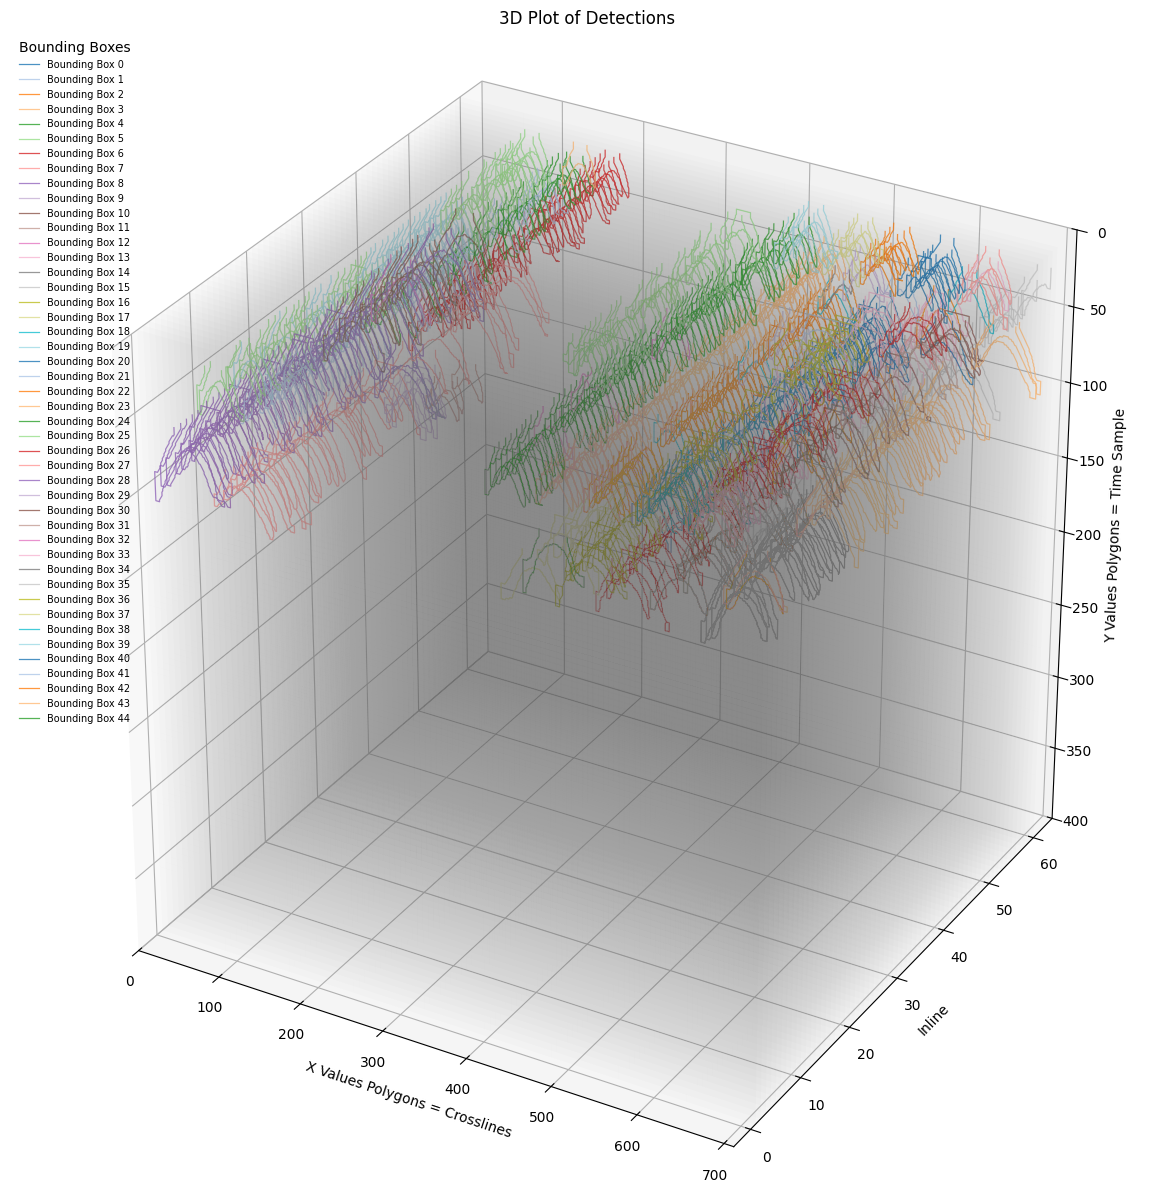

In [ ]:
plot_matched_detections(df = matched_detections)

This looks better but still there has to be a way to see if all detections are displayed in the csv and the plot. sot the next step is to create a function which compares the number of polygons in the csv or Dataframe with the number of detections from YOLO.

In [38]:
def validate_detections(matched_detections,results, csv:bool = False, csv_path:str = None):

    if csv:
        matched_df = pd.read_csv(csv_path, sep=",")
    else:
        matched_df = matched_detections

    number_detections_csv_total = matched_df.shape[0]
    number_of_detections_results = 0

    for result in results:
        if result.masks.xy is not None:
            number_of_detections_results += len(result.masks.xy)

    if number_detections_csv_total == number_of_detections_results:
        print("Detections YOLO matching with Matched Detections")
    
    else:
        print(f"Yolo Detections:{number_of_detections_results} Number of Matched Detections {number_detections_csv_total}")

    


In [39]:
validate_detections(matched_detections=matched_detections,results=results)

Detections YOLO matching with Matched Detections


#### Chapter 5: Fitting Hyperbolas with multiple Linear Regression

For fitting the Hyperbolas on the polygon data the idea is to use
Multiple Linear Regression for the cylindric hyperboloid.
The corresponding formula is:

t² = (4 / v²) · (x – x₀)² + t₀²

Expanding the square gives the linear-regression-compatible form:

t² = b₀ + b₁ x + b₂ x²

with the coefficients:

b₂ = 4 / v²  
b₁ = –8 x₀ / v²  
b₀ = 4 x₀² / v² + t₀²

After the regression the physical parameters are recovered via:

v   = 2 / √b₂  
x₀  = – b₁ / (4 b₂)  
t₀  = √( b₀ – b₁² / (4 b₂) )


The next Function is a fit for every Polygon on every cut 

In [7]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import json

def fit_hyperbolas_on_every_cut(df, csv:bool=False, csv_path:str = None):
    if csv:
        df = pd.read_csv(csv_path)
    else:
        df = df

    fits = []
    for i, row in df.iterrows():
        #Fit Hyperbolas with multiplie Regression
        polygon =  json.loads(row["polygon_data"])
        bbox = row["bbox_number"]
        polygon = np.array(polygon)
        x = polygon[:,0]
        t = polygon[:,1]
        t = t

        y = t**2
        X = np.column_stack([np.ones_like(x), x, x**2])
        model = LinearRegression(fit_intercept=False)
        model.fit(X,y)

        print(f"polygon:{i} in bbox:{bbox} , coefficients{model.coef_}")
        b0, b1, b2 = model.coef_

        #Convert Coefficients to Hyperbel context
        v = np.sqrt((4/b2))
        x0 = (-b1) / (2*b2)
        t0 = np.sqrt(b0 -b1**2 / ( 4*b2))

        fits.append({
            "filename": row["filename"],
            "cut_number": row["cut_number"],
            "bbox_number":row["bbox_number"],
            "b0_Model": b0,
            "b1_Model": b1,
            "b2_Model": b2,
            "v":v,
            "x0":x0,
            "t0":t0,
            "X_Data":x,
            "t_data":t
        })
    
    fits_df = pd.DataFrame(fits)
    
    return fits_df




    

In [7]:
fits_per_cut = fit_hyperbolas_on_every_cut(df=matched_detections)

polygon:0 in bbox:0 , coefficients[ 6.7336e+05     -2295.5      1.9574]
polygon:1 in bbox:1 , coefficients[      35976     -496.32      1.7291]
polygon:2 in bbox:2 , coefficients[ 4.1882e+05     -1573.1      1.4785]
polygon:3 in bbox:3 , coefficients[ 3.3732e+05     -1397.2      1.4485]
polygon:4 in bbox:4 , coefficients[ 1.3456e+06     -4804.4      4.3026]
polygon:5 in bbox:5 , coefficients[ 3.4685e+05     -1626.1      1.9077]
polygon:6 in bbox:6 , coefficients[ 1.4043e+06     -4583.9      3.7522]
polygon:7 in bbox:7 , coefficients[      14973     -326.53      1.8303]
polygon:8 in bbox:8 , coefficients[ 4.9719e+05     -1409.9      1.0002]
polygon:9 in bbox:9 , coefficients[ 1.8842e+06     -5551.2      4.0963]
polygon:10 in bbox:2 , coefficients[ 5.6214e+05     -2119.6      1.9986]
polygon:11 in bbox:4 , coefficients[ 9.5162e+05       -3402      3.0556]
polygon:12 in bbox:5 , coefficients[ 3.5963e+05     -1702.2      2.0161]
polygon:13 in bbox:1 , coefficients[      47702     -652.07  

In [13]:
fits_per_cut

,filename,cut_number,bbox_number,b0_Model,b1_Model,b2_Model,v,x0,t0,X_Data,t_data
0,UG3DQUERUNTERZUG.SGY,1,0,6.733620e+05,-2295.541542,1.957444,1.429504,586.362013,18.783868,"[575.4656372070312, 575.4656372070312, 572.132...","[11.140625, 15.584375381469727, 18.91718864440..."
1,UG3DQUERUNTERZUG.SGY,1,1,3.597606e+04,-496.320463,1.729106,1.520965,143.519396,18.980420,"[133.3125, 133.3125, 132.20156860351562, 132.2...","[6.696875095367432, 11.140625, 12.251563072204..."
2,UG3DQUERUNTERZUG.SGY,1,2,4.188180e+05,-1573.140898,1.478531,1.644806,531.994458,19.153653,"[522.140625, 522.140625, 518.8078002929688, 51...","[11.140625, 14.473437309265137, 17.80624961853..."
3,UG3DQUERUNTERZUG.SGY,1,3,3.373212e+05,-1397.179264,1.448499,1.661770,482.285245,20.043861,"[469.92657470703125, 469.92657470703125, 466.5...","[11.140625, 15.584375381469727, 18.91718864440..."
4,UG3DQUERUNTERZUG.SGY,1,4,1.345641e+06,-4804.373712,4.302608,0.964193,558.309478,66.915642,"[543.2484130859375, 543.2484130859375, 534.360...","[60.02187728881836, 63.35468673706055, 72.2421..."
...,...,...,...,...,...,...,...,...,...,...,...
738,UG3DQUERUNTERZUG.SGY,9,15,8.158030e+05,-3218.824129,3.194372,1.119018,503.827349,70.265117,"[488.8125, 488.8125, 481.03594970703125, 481.0...","[60.02187728881836, 63.35468673706055, 71.1312..."
739,UG3DQUERUNTERZUG.SGY,9,10,8.436778e+04,-566.114694,0.955589,2.045947,296.212493,22.861767,"[287.7328186035156, 287.7328186035156, 283.289...","[11.140625, 14.473437309265137, 18.91718864440..."
740,UG3DQUERUNTERZUG.SGY,9,6,1.235447e+06,-4077.690652,3.376905,1.088355,603.761535,66.863385,"[595.4625244140625, 595.4625244140625, 585.464...","[55.578125, 58.91093826293945, 68.909378051757..."
741,UG3DQUERUNTERZUG.SGY,9,5,4.316134e+05,-2049.415292,2.434610,1.281785,420.891918,17.950069,"[411.046875, 411.046875, 409.9359436035156, 40...","[11.140625, 15.584375381469727, 16.6953125, 16..."


Here is a plot function implemented which plots those fits

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib.cm import get_cmap

def plot_hyperbolas_3d(fits_df):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Jeder bbox_number bekommt konstante Farbe
    bbox_ids = sorted(fits_df["bbox_number"].unique())
    cmap = get_cmap("tab20")
    color_map = {bbox: cmap(i % 20) for i, bbox in enumerate(bbox_ids)}

    for idx, row in fits_df.iterrows():
        x = row["X_Data"]
        t = row["t_data"]
        y = np.full_like(x, row["cut_number"])  # Cut-Nummer als y-Achse
        bbox = row["bbox_number"]
        v = row["v"]
        x0 = row["x0"]
        t0 = row["t0"]
        color = color_map[bbox]

        # Hyperbel erzeugen
        x_fit = x
        t_fit = np.sqrt((4/v**2) * (x_fit - x0)**2 + t0**2)
        y_fit = np.full_like(x_fit, row["cut_number"])

        # Polygonpunkte
        #ax.scatter(x, y, t, color=color, s=10)

        # Gefittete Hyperbel
        ax.plot(x_fit, y_fit, t_fit, color=color, linewidth=2)

        # Apex
        ax.scatter([x0], [row["cut_number"]], [t0],
                   color=color, marker="x", s=80)

    ax.set_xlabel("x (Pixel)")
    ax.set_ylabel("cut_number (Inline / y-Richtung)")
    ax.set_zlabel("t (inverted Pixel/Time)")

    ax.invert_zaxis()  # damit Zeit nach unten größer wird (GPR-like)

    plt.title("3D Hyperbel-Fits (Hyperbolic Cylinder)")
    plt.show()


C:\Users\gijo\AppData\Local\Temp\ipykernel_26336\999500307.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


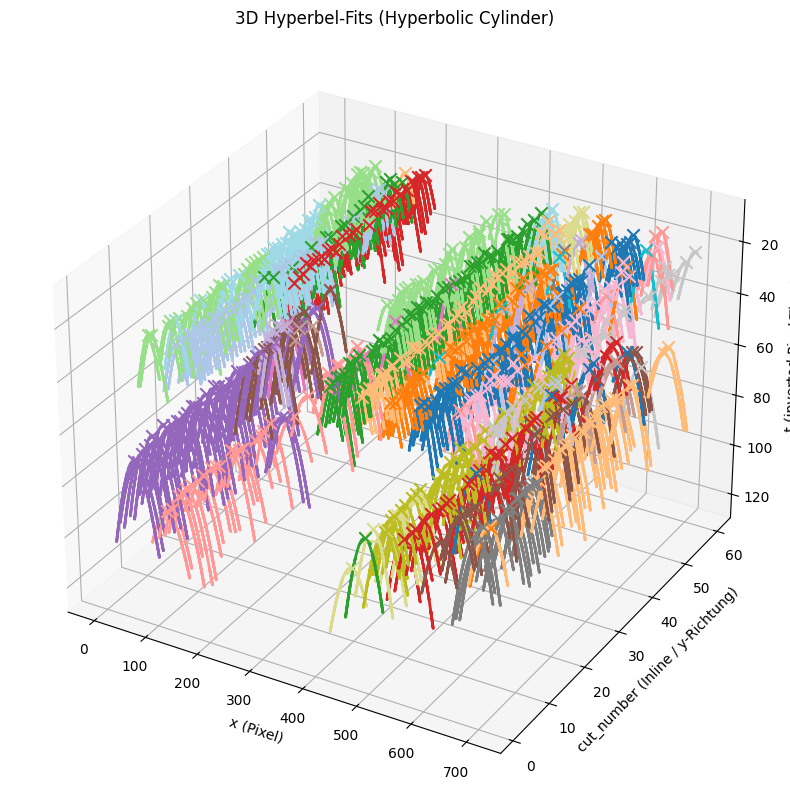

In [50]:
plot_hyperbolas_3d(fits)

Next step ist to create a fit function which is idealised which means. The Hyperbola fit is made on all of the Polygon Data per bbox which after that is then streched out to all Cuts which then is a surface. This helps because it delivers only one t0,v,x0 per matched detection. So it can be seen as a summary of all of the detected Data per matched detections which results in a Surface

In [8]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import json

def fit_hyperbolas_idealized(df, csv:bool=False, csv_path:str = None,):
    if csv:
        df = pd.read_csv(csv_path)
    else:
        df = df

    fits = []

    grouped = df.groupby("bbox_number")

    for bbox, group in grouped:
        #Fit Hyperbolas with multiplie Regression
        every_x = []
        every_t = []

        filenames = group["filename"].unique().tolist()
        cuts = group["cut_number"].unique().tolist()

        for i, row in group.iterrows():

            polygon =  json.loads(row["polygon_data"])
            polygon = np.array(polygon)
            x = polygon[:,0]
            t = polygon[:,1]

            every_x.append(x)
            every_t.append(t)
        
        every_x = np.hstack(every_x)
        every_t = np.hstack(every_t)

        y = every_t**2
        X = np.column_stack([np.ones_like(every_x), every_x, every_x**2])
        model = LinearRegression(fit_intercept=False)
        model.fit(X,y)

        print(f"fit for bbox: {bbox}, coefficients{model.coef_}")
        b0, b1, b2 = model.coef_

        #Convert Coefficients to Hyperbel context
        v = np.sqrt((4/b2))
        x0 = (-b1) / (2*b2)
        t0 = np.sqrt(b0 -b1**2 / ( 4*b2))

        fits.append({
            "bbox": bbox,
            "filename": filenames,
            "cut_number": cuts,
            "b0_Model": b0,
            "b1_Model": b1,
            "b2_Model": b2,
            "v":v,
            "x0":x0,
            "t0":t0,
            "X_Data":every_x,
            "t_data":every_t
        })
    
    fits_df = pd.DataFrame(fits)

    
    return fits_df




    

In [ ]:
idelaized_fit = fit_hyperbolas_idealized(df=matched_detections)

fit for bbox: 0, coefficients[   6.31e+05     -2157.3       1.845]
fit for bbox: 1, coefficients[      39885     -543.38      1.8754]
fit for bbox: 2, coefficients[ 4.8424e+05       -1826      1.7228]
fit for bbox: 3, coefficients[ 3.2972e+05     -1363.3      1.4113]
fit for bbox: 4, coefficients[   6.64e+05       -2350      2.0951]
fit for bbox: 5, coefficients[  2.588e+05     -1218.9      1.4379]
fit for bbox: 6, coefficients[ 1.0113e+06       -3333      2.7579]
fit for bbox: 7, coefficients[      14845     -326.88      1.8692]
fit for bbox: 8, coefficients[ 8.8233e+05     -2514.1      1.7918]
fit for bbox: 9, coefficients[ 1.1115e+06     -3311.5      2.4758]
fit for bbox: 10, coefficients[ 1.0166e+05     -676.93      1.1321]
fit for bbox: 11, coefficients[ 1.1808e+05     -884.27      1.6604]
fit for bbox: 12, coefficients[ 6.8398e+05       -2149      1.6892]
fit for bbox: 13, coefficients[      10686     -252.47      3.0009]
fit for bbox: 14, coefficients[      49812      -767.8    

In [18]:
idelaized_fit

,bbox,filename,cut_number,b0_Model,b1_Model,b2_Model,v,x0,t0,X_Data,t_data
0,0,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",6.310035e+05,-2157.258415,1.845049,1.472401,584.607320,20.712493,"[575.4656372070312, 575.4656372070312, 572.132...","[11.140625, 15.584375381469727, 18.91718864440..."
1,1,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",3.988497e+04,-543.377157,1.875443,1.460421,144.866337,22.944272,"[133.3125, 133.3125, 132.20156860351562, 132.2...","[6.696875095367432, 11.140625, 12.251563072204..."
2,2,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 14, 16, 17, 18, 19, 2, 20, 21, 22,...",4.842417e+05,-1826.008358,1.722784,1.523753,529.958504,19.681881,"[522.140625, 522.140625, 518.8078002929688, 51...","[11.140625, 14.473437309265137, 17.80624961853..."
3,3,[UG3DQUERUNTERZUG.SGY],"[1, 11, 12, 13, 14, 15, 18, 19, 2, 20, 21, 24,...",3.964244e+05,-1642.194442,1.702469,1.532818,482.298033,20.269475,"[469.92657470703125, 469.92657470703125, 466.5...","[11.140625, 15.584375381469727, 18.91718864440..."
4,4,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 16, 17, 18, 19, 20, 21, 22...",6.640000e+05,-2350.008621,2.095133,1.381733,560.825526,70.905275,"[543.2484130859375, 543.2484130859375, 534.360...","[60.02187728881836, 63.35468673706055, 72.2421..."
5,5,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 2, 20,...",2.587994e+05,-1218.896235,1.437941,1.667859,423.833765,22.242420,"[415.4906311035156, 415.4906311035156, 413.268...","[6.696875095367432, 10.029687881469727, 12.251..."
6,6,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 18, 19, 2, 21, 23, 24, 25,...",1.042544e+06,-3433.841826,2.839110,1.186968,604.739180,65.227555,"[596.5734252929688, 596.5734252929688, 595.462...","[55.578125, 60.02187728881836, 61.1328125, 61...."
7,7,[UG3DQUERUNTERZUG.SGY],"[1, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20,...",1.484485e+04,-326.879666,1.869167,1.462871,87.439920,23.530416,"[78.8765640258789, 78.8765640258789, 77.765625...","[11.140625, 14.473437309265137, 15.58437538146..."
8,8,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",8.823292e+05,-2514.096190,1.791783,1.494126,701.562848,20.758558,"[693.2249755859375, 693.2249755859375, 692.114...","[11.140625, 15.584375381469727, 16.6953125, 17..."
9,9,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",1.153943e+06,-3434.757177,2.565354,1.248695,669.450800,65.130961,"[668.7843627929688, 668.7843627929688, 666.562...","[46.69062423706055, 50.0234375, 52.24531173706..."


and finally for the fits a function is created which makes both fits and returns both dfs so that only one function has to be called for fitting.

In [9]:
import pandas as pd

def fit_hyperbolas(matched_detections, export_csv:bool = False, save_path:str = None):
    
    idelaized_fit = fit_hyperbolas_idealized(df =matched_detections)
    fits_per_cut = fit_hyperbolas_on_every_cut(df=matched_detections)

    if export_csv:
        idelaized_fit.to_csv(f"{save_path}/idealized_fit.csv", index=False)
        fits_per_cut.to_csv(f"{save_path}/fits_per_cut.csv", index=False)
        return idelaized_fit, fits_per_cut
    else:
        return idelaized_fit,fits_per_cut


    

In [10]:
idelaized_fit, fits_per_cut = fit_hyperbolas(matched_detections=matched_detections)

fit for bbox: 0, coefficients[   6.31e+05     -2157.3       1.845]
fit for bbox: 1, coefficients[      39885     -543.38      1.8754]
fit for bbox: 2, coefficients[ 4.8424e+05       -1826      1.7228]
fit for bbox: 3, coefficients[ 3.2972e+05     -1363.3      1.4113]
fit for bbox: 4, coefficients[   6.64e+05       -2350      2.0951]
fit for bbox: 5, coefficients[  2.588e+05     -1218.9      1.4379]
fit for bbox: 6, coefficients[ 1.0113e+06       -3333      2.7579]
fit for bbox: 7, coefficients[      14845     -326.88      1.8692]
fit for bbox: 8, coefficients[ 8.8233e+05     -2514.1      1.7918]
fit for bbox: 9, coefficients[ 1.1115e+06     -3311.5      2.4758]
fit for bbox: 10, coefficients[ 1.0166e+05     -676.93      1.1321]
fit for bbox: 11, coefficients[ 1.1808e+05     -884.27      1.6604]
fit for bbox: 12, coefficients[ 6.8398e+05       -2149      1.6892]
fit for bbox: 13, coefficients[      10686     -252.47      3.0009]
fit for bbox: 14, coefficients[      49812      -767.8    

There are now two fit Options. but the values that are calculated are pixel values. The Next step is to translate them into the Values of the Data. Important Information like Trace_Sample_interval is extractet from the Binary File header or the Trace Header. With this information the time Acis can be calculated. for the axis in meters for the crosslines there is only information found in the videos which should be around 4 Meters. Next step is now to implement a function which calculates the Time axis from the Headers with additional parameters for the function which can be used as input for the crossline axis and inline axis.

In [11]:
#Loading SGY File with Datatoolkit
from Pipeline.Datatoolkit import DatatoolKit
dk = DatatoolKit(TEST_FILE_DIR , "UG3DQUERUNTERZUG.SGY")
file = dk.LoadSGY()
df = dk.create_df(file)


In [ ]:
import segyio

def get_axis_and_sample_rate(sgy_file,df):
    number_of_crosslines = len(df["crossline"].unique())
    number_of_inlines = len(df["inline"].unique())
    bin_header_file = dict(sgy_file.bin)
    sampels_per_trace = bin_header_file[segyio.BinField.Samples]
    sample_rate = bin_header_file[segyio.BinField.Interval]

    return number_of_crosslines, number_of_inlines, sampels_per_trace, sample_rate


def help_function_physical_units(sample_rate, sample_rate_factor, number_of_crosslines, number_of_inlines, width_crosslines:int = None, width_inlines:int = None):
    #getting the time per pixel
    time_per_pixel = sample_rate/sample_rate_factor

    #getting distance per pixel for crossline
    distance_per_pixel_crosslines = width_crosslines/number_of_crosslines

    #getting distance per pixel for inlines
    distance_per_pixel_inlines = width_inlines/number_of_inlines

    return time_per_pixel, distance_per_pixel_crosslines, distance_per_pixel_inlines

def convert_phys_params(df, dcrosslines, dtime):
    dcrosslines = float(dcrosslines)
    dtime = float(dtime)
    df = df.copy()
    df["x0_m"] = df["x0"] * dcrosslines
    df["t0_ns"] = df["t0"] * dtime
    df["v_m/ns"] = df["v"] * (dcrosslines/dtime)
    return df

### Chapter 7: Inteactive Plot
Now a Plot Function is implemented whic is 3D and interactive because it gives then more insight to the fitted Data the plot contains diffrent Tabs which are:

- Detected Polygons in 3D context
- Fits per cuts
- Apexes of fits per cut
- Idealized plot
- apexes of idelazied plot as line

In [20]:
import plotly.io as pio
pio.renderers.default = "browser"

import plotly.graph_objects as go
import numpy as np
import json
from matplotlib.cm import get_cmap


def plot_hyperbolas_3d_interactive(
        fits_per_cut_df, fit_idealized_df, matched_detections,
        physics_enabled,
        width_crosslines=None, width_inlines=None):

    number_of_crosslines, number_of_inlines, sampels_per_trace, sample_rate = \
        get_axis_and_sample_rate(sgy_file=file, df=df)

    if physics_enabled:
        if width_inlines is None or width_crosslines is None:
            raise ValueError("Width Inline or Width crosslines cant be empty when physics enabled")

        time_per_pixel, distance_per_pixel_crosslines, distance_per_pixel_inlines = \
            help_function_physical_units(
                sample_rate=sample_rate,
                number_of_crosslines=number_of_crosslines,
                number_of_inlines=number_of_inlines,
                width_crosslines=width_crosslines,
                width_inlines=width_inlines
            )

        fits_per_cut_df = convert_phys_params(
            df=fits_per_cut_df,
            dcrosslines=distance_per_pixel_crosslines,
            dtime=time_per_pixel
        )

        fit_idealized_df = convert_phys_params(
            df=fit_idealized_df,
            dcrosslines=distance_per_pixel_crosslines,
            dtime=time_per_pixel
        )

    # FIGURE
    fig = go.Figure()
    cmap = get_cmap("tab20")

    traces_hyper = []
    traces_apex = []
    traces_poly = []
    traces_surface = []
    traces_surface_apex = []

    # ----------------------------------------------------
    # IDEALISIERTE FLÄCHEN + APEX-LINIEN
    # ----------------------------------------------------
    for _, row in fit_idealized_df.iterrows():

        bbox = int(row["bbox"])
        cuts = row["cut_number"]
        v_raw, x0_raw, t0_raw = row["v"], row["x0"], row["t0"]

        r, g, b, a = cmap(bbox % 20)
        col = f"rgba({255*r:.0f},{255*g:.0f},{255*b:.0f},0.7)"

        xmin, xmax = min(row["X_Data"]), max(row["X_Data"])
        cmin, cmax = min(cuts), max(cuts)

        xf = np.linspace(xmin, xmax, 60)
        yf = np.linspace(cmin, cmax, 60)

        Xg, Yg = np.meshgrid(xf, yf)
        Zg = np.sqrt((4 / v_raw**2) * (Xg - x0_raw)**2 + t0_raw**2)

        traces_surface.append(len(fig.data))
        fig.add_trace(go.Surface(
            x=Xg, y=Yg, z=Zg,
            opacity=0.5,
            showscale=False,
            colorscale=[[0, col], [1, col]],
            visible=False
        ))

        # ===== APEX-LINIE =====
        y_line = np.linspace(cmin, cmax, 50)
        x_line = np.full_like(y_line, x0_raw)
        z_line = np.full_like(y_line, t0_raw)

        # Hover Daten
        if physics_enabled:
            x0_m = row["x0_m"]
            t0_ns = row["t0_ns"]
            v_m_ns = row["v_m/ns"]

            hovertemplate = (
                "<b>Idealisiert Apex</b><br>"
                "x0 = %{customdata[0]:.1f} px (%{customdata[1]:.3f} m)<br>"
                "t0 = %{customdata[2]:.1f} samp (%{customdata[3]:.1f} ns)<br>"
                "v = %{customdata[4]:.3f} px/samp (%{customdata[5]:.6f} m/ns)<br>"
                "<extra></extra>"
            )

            base = [x0_raw, x0_m, t0_raw, t0_ns, v_raw, v_m_ns]

        else:
            hovertemplate = (
                "<b>Idealisiert Apex</b><br>"
                "x0 = %{customdata[0]:.1f} px<br>"
                "t0 = %{customdata[1]:.1f} samp<br>"
                "v = %{customdata[2]:.2f} px/samp<br>"
                "<extra></extra>"
            )

            base = [x0_raw, t0_raw, v_raw]

        # customdata für jeden Punkt replizieren
        customdata = np.tile([base], (len(x_line), 1))

        traces_surface_apex.append(len(fig.data))
        fig.add_trace(
            go.Scatter3d(
                x=x_line, y=y_line, z=z_line,
                mode="lines",
                line=dict(color=col, width=5),
                visible=False,
                hovertemplate=hovertemplate,
                hoverinfo="text",
                customdata=customdata
            )
        )

    # ----------------------------------------------------
    # HYPERBELN PRO CUT + APEX-PUNKT
    # ----------------------------------------------------
    for _, row in fits_per_cut_df.iterrows():

        bbox = int(row["bbox_number"])
        cut = int(row["cut_number"])
        X = np.array(row["X_Data"])

        v_raw, x0_raw, t0_raw = row["v"], row["x0"], row["t0"]

        r, g, b, a = cmap(bbox % 20)
        col = f"rgba({255*r:.0f},{255*g:.0f},{255*b:.0f},{a})"

        xf = np.linspace(X.min(), X.max(), 150)
        yf = np.full_like(xf, cut)
        tf = np.sqrt((4 / v_raw**2) * (xf - x0_raw)**2 + t0_raw**2)

        traces_hyper.append(len(fig.data))
        fig.add_trace(go.Scatter3d(
            x=xf, y=yf, z=tf,
            mode="lines",
            line=dict(color=col, width=4),
            visible=True
        ))

        # ===== APEX-PUNKT =====
        if physics_enabled:
            x0_m = row["x0_m"]
            t0_ns = row["t0_ns"]
            v_m_ns = row["v_m/ns"]

            hovertemplate = (
                "<b>Apex</b><br>"
                "x0 = %{customdata[0]:.1f} px (%{customdata[1]:.3f} m)<br>"
                "t0 = %{customdata[2]:.1f} samp (%{customdata[3]:.1f} ns)<br>"
                "v = %{customdata[4]:.3f} px/samp (%{customdata[5]:.6f} m/ns)<br>"
                "<extra></extra>"
            )

            customdata = [[x0_raw, x0_m, t0_raw, t0_ns, v_raw, v_m_ns]]

        else:
            hovertemplate = (
                "<b>Apex</b><br>"
                "x0 = %{customdata[0]:.1f} px<br>"
                "t0 = %{customdata[1]:.1f} samp<br>"
                "v = %{customdata[2]:.2f} px/samp<br>"
                "<extra></extra>"
            )

            customdata = [[x0_raw, t0_raw, v_raw]]

        traces_apex.append(len(fig.data))
        fig.add_trace(go.Scatter3d(
            x=[x0_raw], y=[cut], z=[t0_raw],
            mode="markers",
            marker=dict(size=6, color=col),
            visible=False,
            hovertemplate=hovertemplate,
            customdata=customdata
        ))

    # ----------------------------------------------------
    # POLYGON-KONTUREN
    # ----------------------------------------------------
    for _, row in matched_detections.iterrows():
        try:
            poly = json.loads(row["polygon_data"])
        except:
            continue

        xs = [p[0] for p in poly]
        zs = [p[1] for p in poly]
        ys = [row["cut_number"]] * len(xs)

        if len(xs) < 2:
            continue

        bbox = int(row["bbox_number"])
        r, g, b, a = cmap(bbox % 20)
        col = f"rgba({255*r:.0f},{255*g:.0f},{255*b:.0f},{a})"

        traces_poly.append(len(fig.data))
        fig.add_trace(go.Scatter3d(
            x=xs, y=ys, z=zs,
            mode="lines",
            line=dict(color=col, width=3),
            visible=False
        ))

    # ----------------------------------------------------
    # BUTTONMASKE
    # ----------------------------------------------------
    def mask(traces):
        vis = [False] * len(fig.data)
        for t in traces:
            vis[t] = True
        return vis

    # ----------------------------------------------------
    # LAYOUT
    # ----------------------------------------------------
    fig.update_layout(
        title="<b>Detektionen und Hyperbeln</b>",
        scene=dict(
            xaxis=dict(title="Crosslines"),
            yaxis=dict(title="Inlines"),
            zaxis=dict(title="Zeit (Samples)", range=[sampels_per_trace, 0])
        ),
        updatemenus=[
            dict(
                type="buttons",
                buttons=[
                    dict(label="Polygone Detektiert",
                         method="update",
                         args=[{"visible": mask(traces_poly)}]),
                    dict(label="Hyperbeln Pro Cut",
                         method="update",
                         args=[{"visible": mask(traces_hyper)}]),
                    dict(label="Scheitelpunkte Pro Hyperbel",
                         method="update",
                         args=[{"visible": mask(traces_apex)}]),
                    dict(label="Hyperbeln Idealisiert",
                         method="update",
                         args=[{"visible": mask(traces_surface)}]),
                    dict(label="Scheitelpunkte Idealisiert",
                         method="update",
                         args=[{"visible": mask(traces_surface_apex)}]),
                ],
                x=0, y=0.85
            )
        ],
        height=700
    )

    fig.show()


In [21]:
plot_hyperbolas_3d_interactive(fits_per_cut_df=fits_per_cut,fit_idealized_df=idelaized_fit,matched_detections=matched_detections,physics_enabled=True,width_crosslines=4, width_inlines=3)

C:\Users\Joris Gisler\AppData\Local\Temp\ipykernel_28284\3800241143.py:45: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



### Chapter 4: Implementation in Pipeline

We can now implement the **ectract_boxes_and_polygons()** which is a update to the **extract_boxes()** to the **Predictor Class**. Now we can make Predictions on diffrent Model types and extract the relevant information for the type of model. Here the two types which where tested are **Object Detection** and **Instance Segmentation**